# 주가와 금리 관계 분석

In [1]:
import FinanceDataReader as fdr
import pandas as pd
import cufflinks as cf
cf.go_offline(connected=True)

## Import Data

In [2]:
# kospi
kospi_df = fdr.DataReader('KS11', '1998')
kospi_df = kospi_df.reset_index()

In [5]:
# https://www.bok.or.kr/portal/singl/baseRate/list.do?dataSeCd=01&menuNo=200643
# 기준 금리 table copy
base_rate_df = pd.read_clipboard(header=None)

In [6]:
base_rate_df['Date'] = pd.to_datetime(base_rate_df[0].astype(str) + base_rate_df[1], format='%Y%m월 %d일')

In [7]:
base_rate_df = base_rate_df[[2, 'Date']]
base_rate_df.columns = ['Base_rate', 'Date']

## Preprocessing

In [8]:
kp_br = kospi_df.merge(base_rate_df, on='Date', how='outer')  # kospi and base rate
kp_br = kp_br[['Date', 'Close', 'Base_rate']]
kp_br = kp_br.fillna(method='ffill')
kp_br['Kospi_scaled'] = (kp_br['Close'] - kp_br['Close'].min()) / (kp_br['Close'].max() - kp_br['Close'].min())
kp_br['Kospi_scaled'] = kp_br['Kospi_scaled'] * kp_br['Base_rate'].max()

In [9]:
kp_br.tail()

,Date,Close,Base_rate,Kospi_scaled
6082,2022-06-14,2492.97,1.75,3.840425
6083,2022-06-15,2447.38,1.75,3.761307
6084,2022-06-16,2451.41,1.75,3.768301
6085,2022-06-17,2440.93,1.75,3.750114
6086,2022-06-20,2391.03,1.75,3.663517


In [17]:
kp_br.iplot(x='Date', y=['Base_rate', 'Kospi_scaled'])

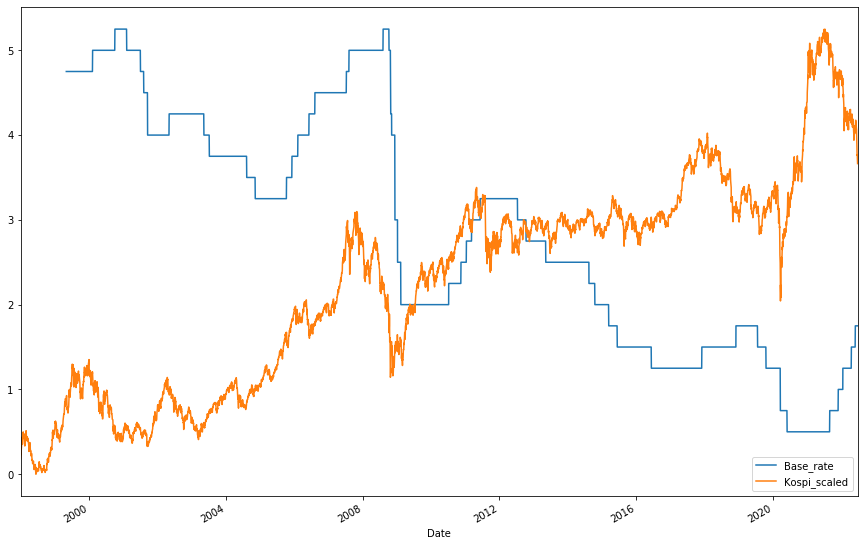

In [53]:
kp_br.plot(x='Date', y=['Base_rate', 'Kospi_scaled'], figsize=(15, 10))**

In [59]:
i,j = 0, 1

In [65]:
base_rate_df = base_rate_df[::-1].reset_index(drop=True)

In [67]:
base_rate_df

,Base_rate,Date
0,4.75,1999-05-06
1,5.00,2000-02-10
2,5.25,2000-10-05
3,5.00,2001-02-08
4,4.75,2001-07-05
5,4.50,2001-08-09
6,4.00,2001-09-19
7,4.25,2002-05-07
8,4.00,2003-05-13
9,3.75,2003-07-10


In [71]:
n = len(base_rate_df)

In [106]:
candidates = []

In [107]:
th = 1
term  = 365

In [108]:
for i in range(n):
    for j in range(i+1, n):
        date_gap = (base_rate_df.loc[j, 'Date'] - base_rate_df.loc[i, 'Date']).days
        if  term < date_gap < 2*term:
            if base_rate_df.loc[j, 'Base_rate'] - base_rate_df.loc[i, 'Base_rate'] >= th:
                candidates.append((i, j))

In [109]:
candidates

[(10, 16),
 (11, 15),
 (11, 16),
 (12, 17),
 (12, 18),
 (13, 17),
 (13, 18),
 (14, 18),
 (44, 48),
 (44, 49)]

In [96]:
base_rate_df.loc[12]

Base_rate                    3.5
Date         2005-10-11 00:00:00
Name: 12, dtype: object

In [92]:
base_rate_df.loc[17]

Base_rate                   4.75
Date         2007-07-12 00:00:00
Name: 17, dtype: object

In [90]:
candidates[0]

(12, 17)

In [74]:
(base_rate_df.loc[j, 'Base_rate'] - base_rate_df.loc[i, 'Base_rate'])

0.0

In [70]:
(base_rate_df.loc[j, 'Date'] - base_rate_df.loc[i, 'Date']).days

280